In [2]:
# 話者Rにおける隣接する発話におけるΔV,ΔA,ΔDを導出
import pandas as pd

# 入力ファイル
input_csv = "/home/mitani/CSJ-emo-int_bunseki/csj_vad_bunseki/speaker_split_noise/speaker_R_cleaned.csv"

# 出力ファイル
output_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/R_bunseki/vad_dis.csv"

# CSV読み込み
df = pd.read_csv(input_csv)

# 隣接発話間の変化量を計算
df["delta_valence"] = df["valence"].diff().abs()
df["delta_arousal"] = df["arousal"].diff().abs()
df["delta_dominance"] = df["dominance"].diff().abs()

# 1行目は比較対象がないため削除
df_diff = df.iloc[1:].copy()

# 必要な列だけ保存したい場合
result = df_diff[
    [
        "filename",
        "text",
        "valence",
        "arousal",
        "dominance",
        "delta_valence",
        "delta_arousal",
        "delta_dominance",
    ]
]

# 保存
result.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"保存完了: {output_csv}")
print(f"発話数: {len(result)}")

保存完了: /home/mitani/CSJ-emo-int_bunseki/0718/R_bunseki/vad_dis.csv
発話数: 255


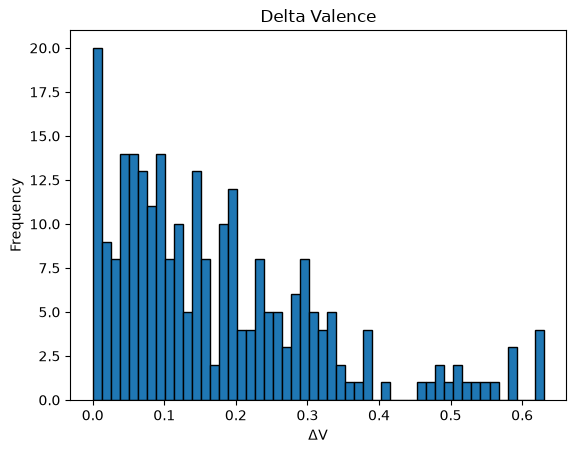

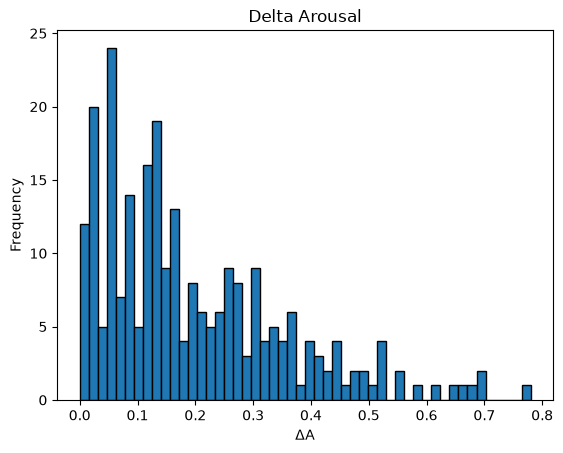

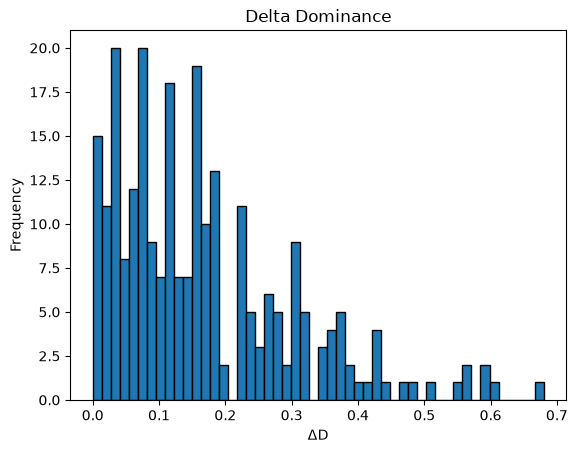

In [3]:
# ΔV,ΔA,ΔDそれぞれの分布で変化量の大きい発話がどんな分布になっているかを確認するためにヒストグラムを作成
import matplotlib.pyplot as plt

plt.hist(result["delta_valence"], bins=50, edgecolor="black")
plt.title("Delta Valence")
plt.xlabel("ΔV")
plt.ylabel("Frequency")
plt.show()

plt.hist(result["delta_arousal"], bins=50, edgecolor="black")
plt.title("Delta Arousal")
plt.xlabel("ΔA")
plt.ylabel("Frequency")
plt.show()

plt.hist(result["delta_dominance"], bins=50, edgecolor="black")
plt.title("Delta Dominance")
plt.xlabel("ΔD")
plt.ylabel("Frequency")
plt.show()

In [4]:
# 変化量の統計値
print(df["delta_valence"].describe())
print("")
print(df["delta_arousal"].describe())
print("")
print(df["delta_dominance"].describe())

count    255.000000
mean       0.173137
std        0.144749
min        0.000000
25%        0.060000
50%        0.140000
75%        0.250000
max        0.630000
Name: delta_valence, dtype: float64

count    255.000000
mean       0.197255
std        0.160239
min        0.000000
25%        0.070000
50%        0.150000
75%        0.290000
max        0.780000
Name: delta_arousal, dtype: float64

count    255.000000
mean       0.166941
std        0.136035
min        0.000000
25%        0.060000
50%        0.140000
75%        0.240000
max        0.680000
Name: delta_dominance, dtype: float64


In [5]:
# 分布上で上位何％にどの程度のデータが入るかを確認し、それの％で閾値候補を決め打ち
print("<delta_valence>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_valence"].quantile(p/100)
    )
print("")

print("<delta_arousal>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_arousal"].quantile(p/100)
    )
print("")

print("<delta_dominance>")
for p in [90,95,97,99]:
    print(
        p,
        df["delta_dominance"].quantile(p/100)
    )
print("")


<delta_valence>
90 0.35
95 0.5029999999999998
97 0.5538
99 0.62

<delta_arousal>
90 0.42599999999999993
95 0.52
97 0.5676
99 0.6846000000000001

<delta_dominance>
90 0.36000000000000004
95 0.43000000000000005
97 0.49139999999999984
99 0.59

